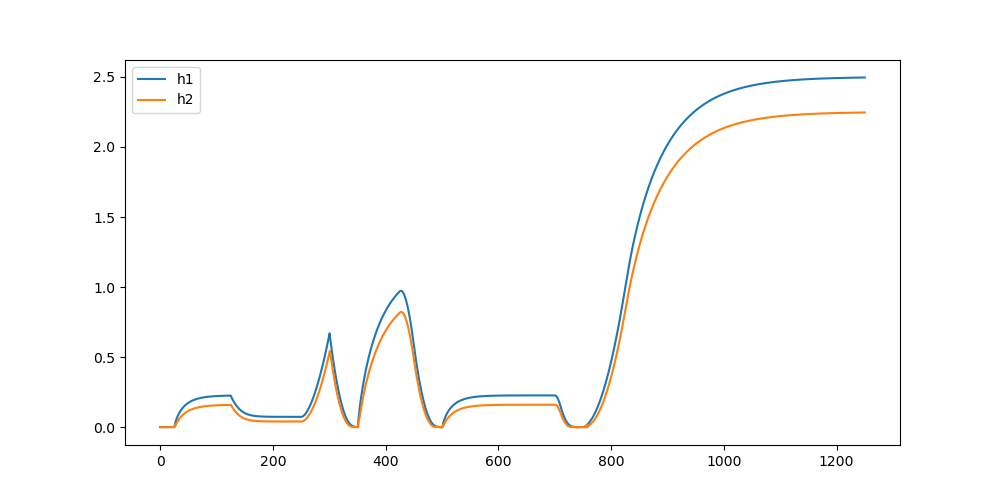

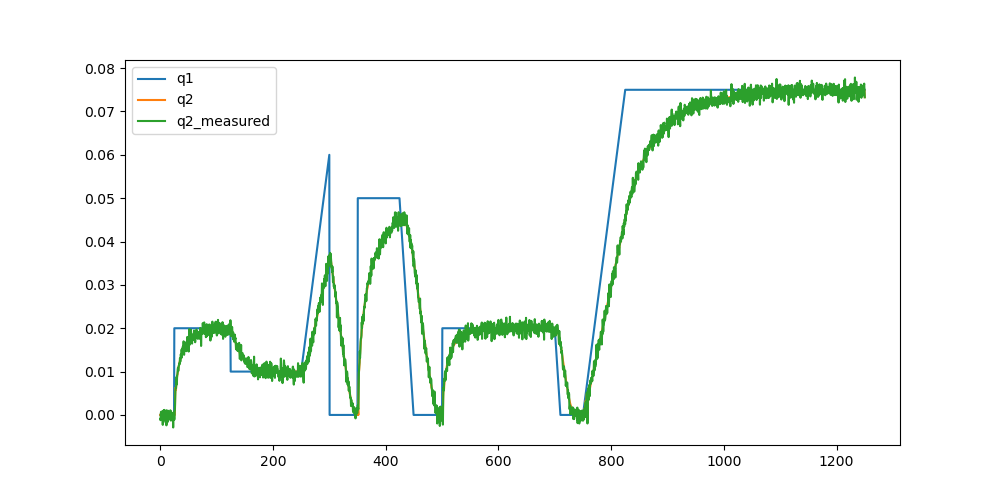

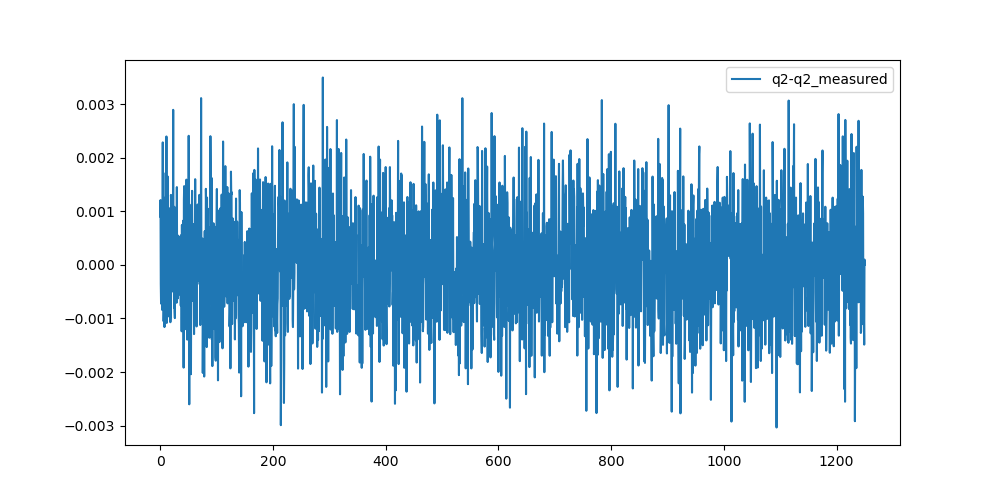

In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from numpy import sqrt
import csv
import typing



plt.style.use('default')
plt.interactive(True)
plt.rcParams['figure.figsize'] = [10, 5]

DATA_FILE_NAME = "./data_main.csv"

class Sample:
    index:int = 0
    
    # from data
    t:float = 0
    q1:float = 0,
    h1:float = 0
    h2:float = 0
    q2_measured:float = 0
    
    # derived
    q2:float = 0
    v1:float = 0 # volume in tank 1
    v2:float = 0 # volume in tank 2
    vt:float = 0 # total volume
    vdif:float = 0
    delta:float = 0 # time delta
    total_inflow:float = 0
    total_outflow:float = 0
    
    prev:typing.Self = None
    next:typing.Self = None

def SamplesFromFile(filename:str)->list[Sample]:
    samples = []
    with open(DATA_FILE_NAME) as file:
        reader = csv.reader(file, delimiter=";")
        i = 0
        total_inflow = 0.0
        for row in reader:
            break
        for row in reader:
            s = Sample()
            s.index = i
            s.t = np.float64(row[0].replace(",", "."))
            s.q1 = np.float64(row[1].replace(",", "."))
            s.h1 = np.float64(row[2].replace(",", "."))
            s.h2 = np.float64(row[3].replace(",", "."))
            s.q2_measured = np.float64(row[4].replace(",", "."))
            # s.t = np.float64(row["t[sec]"].replace(",", "."))
            # s.q1 = float(row["q1[m3/h]"].replace(",", "."))
            # print(row["q1[m3/h]"])
            # s.h1 = np.float64(row["h1[m]"].replace(",", "."))
            # s.h2 = np.float64(row["h2[m]"].replace(",", "."))
            # s.q2_measured = np.float64(row["q2_measurement[m3/h]"].replace(",", "."))
            if i != 0:
                samples[i-1].next = s
                s.prev = samples[i-1]
                s.delta =  s.t-s.prev.t
                s.total_inflow = total_inflow 
            samples.append(s)
            total_inflow += s.q1
            i+=1
    return samples


class Dataset:
    name:str = ""

    n:int = 0

    samples:list[Sample] = []

    # for convenience
    t:npt.ArrayLike = []
    h1:npt.ArrayLike = []
    h2:npt.ArrayLike = []
    v1:npt.ArrayLike = []
    v2:npt.ArrayLike = []
    q1:npt.ArrayLike = []
    q2:npt.ArrayLike = []
    q2_measured:npt.ArrayLike = []

    total_time:float = 0
    S1:float = 0
    S2:float = 0
    a:float = 0
    k:float = 0
    inflow_start_index:int = 0

    total_inflow:float = 0
    total_outflow:float = 0

    def __init__(self, filename:str):
        samples = SamplesFromFile(filename)
        i = 0
        while samples[i].q1 == 0:
            i += 1
        s = samples[i]
        self.inflow_start_index = i
        self.S1 = s.q1 / s.next.h1

        ft2 = (samples[i].q1+samples[i+1].q1)
        self.S2 = (ft2 - self.S1*samples[i+2].h1) / samples[i+2].h2

        for s in samples:
            s.v1 = self.S1 * s.h1
            s.v2 = self.S2 * s.h2
            s.vt = s.v1 + s.v2
            if s.prev is not None:
                vexp = s.prev.vt + s.prev.q1
                s.prev.vdif = vexp-s.vt
                s.prev.q2 = ((vexp-s.vt))
                self.total_outflow += s.prev.q2
                #s.q2 = sqrt(s.prev.h2) * self.k
                #self.total_outflow += s.q2
                s.prev.total_outflow = self.total_outflow

        samples[-1].q2 = samples[-1].q2_measured
        samples[-1].vt = samples[-2].vt
        samples[-1].v1 = samples[-2].v1
        samples[-1].v2 = samples[-2].v2

        self.a = samples[self.inflow_start_index+2].v2 / samples[self.inflow_start_index+1].h1
        self.k = samples[self.inflow_start_index+3].q2 / samples[self.inflow_start_index+2].h2

        # Stupidly unoptimized, but shouldn't matter
        self.t = np.array([s.t for s in samples])
        self.h1 = np.array([s.h1 for s in samples])
        self.h2 = np.array([s.h2 for s in samples])
        self.v1 = np.array([s.v1 for s in samples])
        self.v2 = np.array([s.v2 for s in samples])
        self.q1 = np.array([s.q1 for s in samples])
        self.q2_measured = np.array([s.q2_measured for s in samples])
        self.q2 = np.array([s.q2 for s in samples])
        self.n = len(samples)
        self.samples = samples
        self.total_time = samples[-1].t
        self.total_inflow = samples[-1].total_inflow


data = Dataset(DATA_FILE_NAME)

fig = plt.figure()
plt.plot(data.t, data.h1, label="h1")
plt.plot(data.t, data.h2, label="h2")
plt.legend()
plt.show()
fig = plt.figure()
plt.plot(data.t, data.q1, label="q1")
plt.plot(data.t, data.q2, label="q2")
plt.plot(data.t, data.q2_measured, label="q2_measured")
plt.interactive(True)
plt.legend()
plt.show()

fig = plt.figure()
plt.plot(data.t, data.q2-data.q2_measured, label="q2-q2_measured")
plt.legend()
plt.show()


